In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

from astropy.io import fits
from astropy.convolution import convolve, convolve_fft
import scipy.io as sio
from scipy import signal
import progressbar

In [47]:
def checkerboard2(s=8):
    return np.kron([[1, 0] * 4, [0, 1] * 4], np.ones((s, s))) 

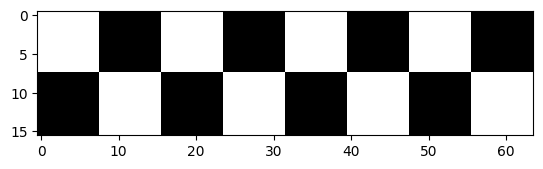

In [50]:
C = checkerboard2(s=8)
plt.imshow(C, cmap='gray')


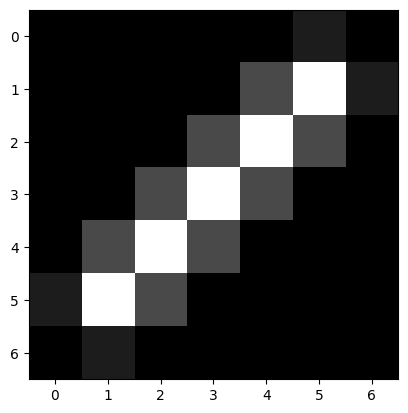

In [16]:
psf = np.load('psf_motion.npy')
plt.imshow(psf, cmap='gray')

In [7]:
def psf2otf(psf, s):
    """
    Get OTF (Optical Transfer Function) from PSF (Point Spread Function)
    OTF is basically the Fourier Transform of the PSF, centered
    psf: PSF 
    s: shape of the result, zero-padding is used to center is Fourier Transform
    """
    
    # computes padding values
    sh = np.array(psf.shape)
    s = np.array(s)
    pad = s - sh
    
    # centers psf
    h_centered = np.pad(psf, ((pad[0]//2+1, pad[0]-pad[0]//2-1), (pad[1]//2+1, pad[1]-pad[1]//2-1)), mode='constant')

    plt.imshow(h_centered)
    plt.title("psf centered")
    plt.show()
    # Fourier transform (aka OTF) of the psf
    h_centered = np.fft.fftshift(h_centered)
    H = np.fft.fft2(h_centered, s)
    
    # Keep only real values (simple approximation)
    H = np.real(H)
    return H

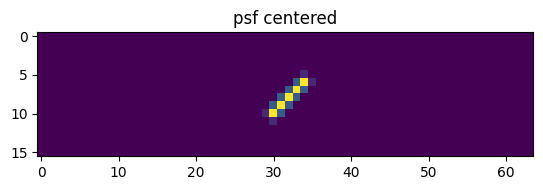

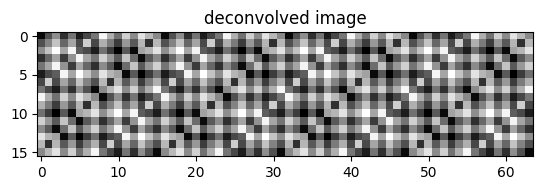

In [17]:

H = psf2otf(psf, s=C.shape)
G=np.fft.fft2(C)
alpha=0.001
F=G/(H+alpha)
fr=np.real(np.fft.ifft2(F))
plt.imshow(fr, cmap='gray')
plt.title("deconvolved image")
plt.show()

In [19]:
def add_gaussian_noise(image, sigma):
    I2=image.copy()
    m=np.min(image)
    M=np.max(image)
    N=(M-m)/sigma*np.random.randn(image.shape[0],  image.shape[1])
    I2+=N
    I2[I2>M ]=M
    I2[I2<m ]=m
    return I2, image-I2

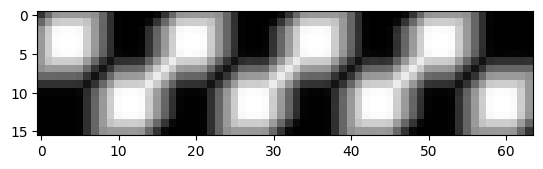

In [35]:
CB=signal.convolve2d(C, psf, mode='same')
Cbn, noise=add_gaussian_noise(CB, sigma=1000)
plt.imshow(Cbn, cmap='gray')

